# LeetCode #17: Letter Combinations of a Phone Number

https://leetcode.com/problems/letter-combinations-of-a-phone-number/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (Iterative BFS)** | $O(4^n \cdot n)$ | $O(4^n \cdot n)$ |
| **Optimal: Backtracking** ★ | $O(4^n \cdot n)$ | $O(n)$ auxiliary |

---

## Understanding the Methods

### Brute Force (Iterative BFS)
Build all combinations level by level: start with an empty list, then for each digit multiply every existing partial string by each of its mapped letters. All in-progress partial strings must live in memory simultaneously at every level.

### Optimal: Backtracking ★
Recursively commit one letter at a time, recurse into the next digit, then undo the choice. Only the current path lives on the call stack — $O(n)$ auxiliary space — and each completed string is written to output exactly once at the leaf.

**Why this is better than Iterative BFS:** The BFS approach holds all $O(4^n)$ partial strings in memory at once during the last level expansion. Backtracking keeps only the current $n$-character path on the stack, making auxiliary space $O(n)$ regardless of output size.

**Constraints:**
* 0 <= digits.length <= 4
* digits[i] is a digit in the range ['2', '9']

## Solutions

### C#

In [ ]:
public class Solution {
    private static readonly Dictionary<char, string> PhoneMap = new() {
        {'2', "abc"}, {'3', "def"}, {'4', "ghi"}, {'5', "jkl"},
        {'6', "mno"}, {'7', "pqrs"}, {'8', "tuv"}, {'9', "wxyz"}
    };

    public IList<string> LetterCombinations(string digits) {
        var result = new List<string>();
        if (digits.Length == 0) return result;
        Backtrack(digits, 0, new StringBuilder(), result);
        return result;
    }

    private void Backtrack(string digits, int index, StringBuilder current, List<string> result) {
        if (index == digits.Length) {
            result.Add(current.ToString());
            return;
        }
        // Try each letter mapped to this digit, then undo
        foreach (char letter in PhoneMap[digits[index]]) {
            current.Append(letter);
            Backtrack(digits, index + 1, current, result);
            current.Remove(current.Length - 1, 1);
        }
    }
}

### Python

In [ ]:
class Solution:
    def letterCombinations(self, digits: str) -> list[str]:
        if not digits:
            return []

        phone_map = {
            '2': 'abc', '3': 'def', '4': 'ghi', '5': 'jkl',
            '6': 'mno', '7': 'pqrs', '8': 'tuv', '9': 'wxyz'
        }
        result = []

        def backtrack(index: int, current: list[str]) -> None:
            if index == len(digits):
                result.append(''.join(current))
                return
            # Try each letter mapped to this digit, then undo
            for letter in phone_map[digits[index]]:
                current.append(letter)
                backtrack(index + 1, current)
                current.pop()

        backtrack(0, [])
        return result

### Go

In [ ]:
func letterCombinations(digits string) []string {
    if len(digits) == 0 {
        return []string{}
    }
    phoneMap := map[byte]string{
        '2': "abc", '3': "def", '4': "ghi", '5': "jkl",
        '6': "mno", '7': "pqrs", '8': "tuv", '9': "wxyz",
    }
    result := []string{}
    var backtrack func(index int, current []byte)
    backtrack = func(index int, current []byte) {
        if index == len(digits) {
            result = append(result, string(current))
            return
        }
        // Try each letter mapped to this digit, then undo via slice length
        for i := 0; i < len(phoneMap[digits[index]]); i++ {
            backtrack(index+1, append(current, phoneMap[digits[index]][i]))
        }
    }
    backtrack(0, []byte{})
    return result
}

### Rust

In [ ]:
impl Solution {
    pub fn letter_combinations(digits: String) -> Vec<String> {
        if digits.is_empty() {
            return vec![];
        }
        let phone_map: Vec<&[u8]> = vec![
            b"", b"", b"abc", b"def", b"ghi",
            b"jkl", b"mno", b"pqrs", b"tuv", b"wxyz",
        ];
        let digit_indices: Vec<usize> = digits.bytes().map(|b| (b - b'0') as usize).collect();
        let mut result = Vec::new();
        let mut current = Vec::new();

        // Inner recursive closure via helper fn
        fn backtrack(
            digit_indices: &[usize], phone_map: &Vec<&[u8]>,
            index: usize, current: &mut Vec<u8>, result: &mut Vec<String>,
        ) {
            if index == digit_indices.len() {
                result.push(String::from_utf8(current.clone()).unwrap());
                return;
            }
            // Try each letter mapped to this digit, then undo
            for &letter in phone_map[digit_indices[index]] {
                current.push(letter);
                backtrack(digit_indices, phone_map, index + 1, current, result);
                current.pop();
            }
        }

        backtrack(&digit_indices, &phone_map, 0, &mut current, &mut result);
        result
    }
}

## Example Scenarios

**1. Common Case**
**Input:** `digits = "23"`
$2 \to$ abc, $3 \to$ def. Backtracking produces $3 \times 3 = 9$ combinations: `["ad","ae","af","bd","be","bf","cd","ce","cf"]`. **Output: 9 strings**

**2. Slightly Complex**
**Input:** `digits = "79"`
$7 \to$ pqrs (4 letters), $9 \to$ wxyz (4 letters). $4 \times 4 = 16$ combinations. Digits with 4-letter mappings are the only ones that expand the output size beyond $3^n$. **Output: 16 strings**

**3. Edge Case: Time Factor**
**Input:** `digits = "7999"`
$4 \times 4 \times 4 \times 4 = 256$ combinations — maximum possible for 4 digits. Every leaf of the recursion tree is visited; the call stack reaches depth 4 on every path. **Output: 256 strings**

**4. Edge Case: Space Factor**
**Input:** `digits = ""`
Empty input — return immediately with no recursion, no stack frames allocated. The auxiliary space is $O(n) = O(0)$; the output list is empty. **Output: []**

**5. Almost-Impossible but Plausible**
**Input:** `digits = "2"`
Single digit: $3$ combinations `["a","b","c"]`. Only one level of recursion, three leaf calls. Demonstrates that the algorithm is correct even at the minimum non-empty input. **Output: ["a","b","c"]**

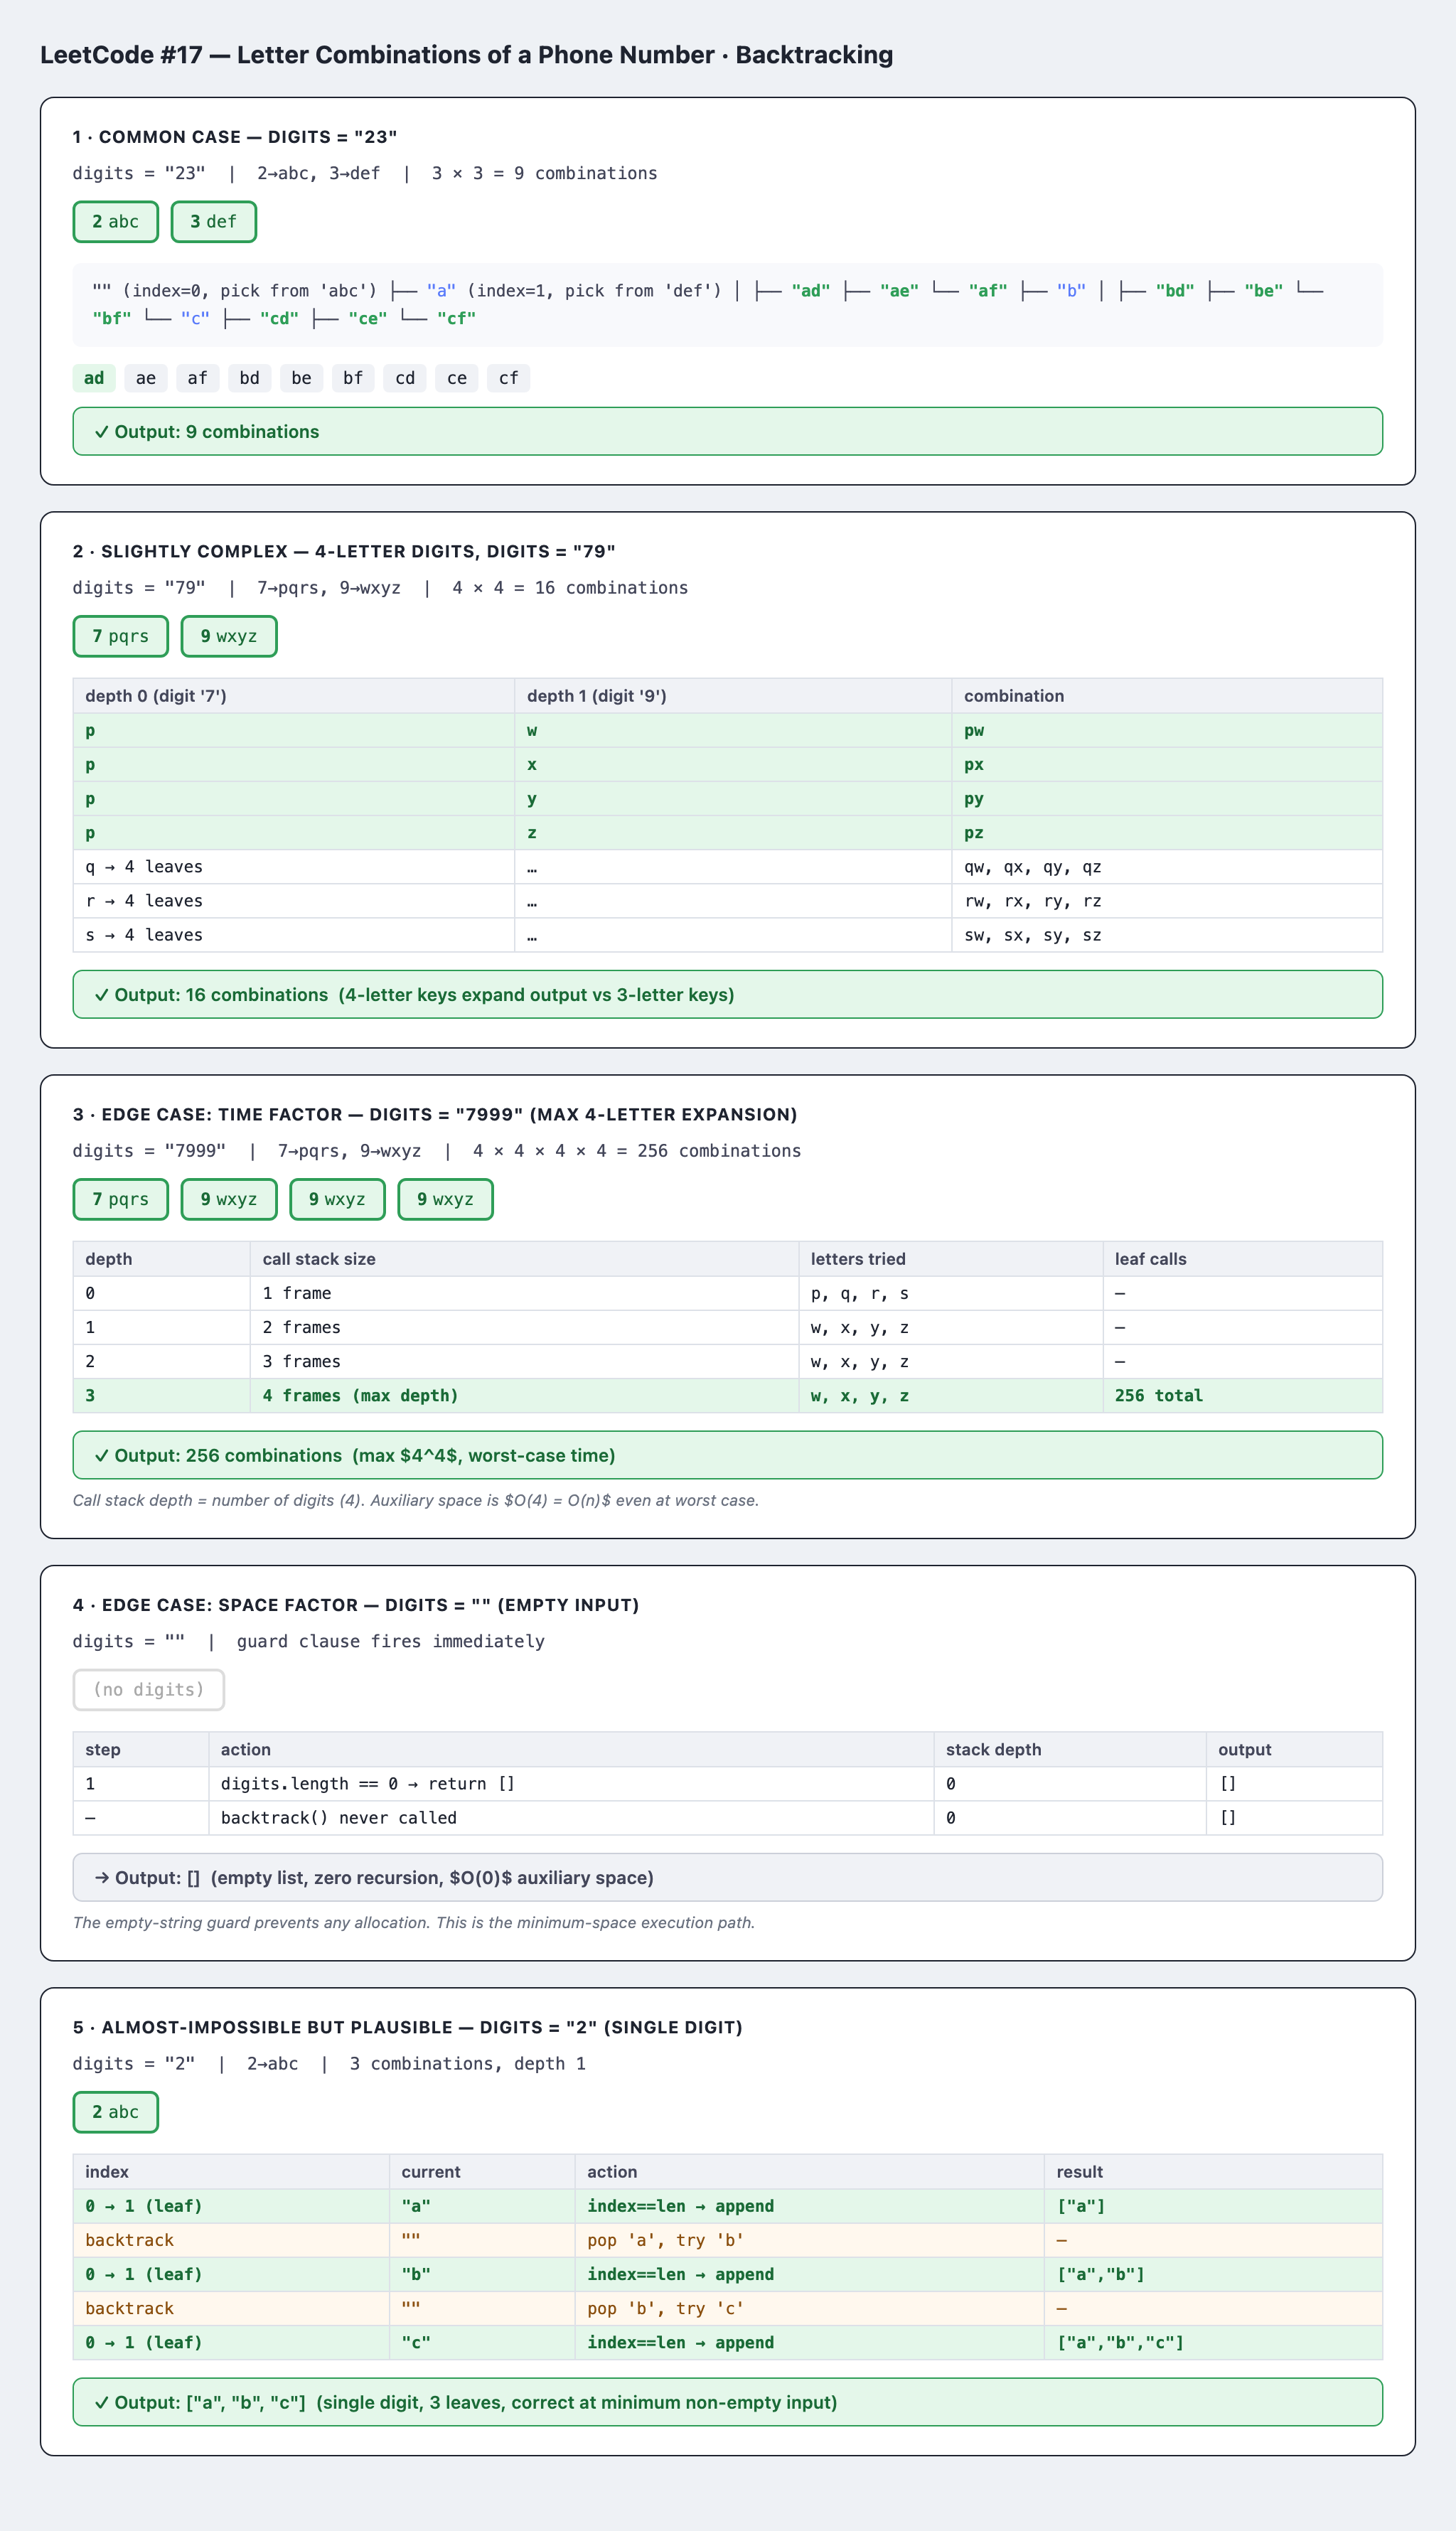